# Decision Trees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


## Data Acquisition

load dataset

In [ ]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [ ]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [ ]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


## Hyperparameter Tuning with GridSearchCV

Decision Trees are prone to overfitting, especially on high-dimensional sparse data like TF-IDF.
We use `GridSearchCV` to systematically find the optimal balance between model complexity and generalization.

**Key Hyperparameters for Decision Trees:**
- `max_depth`: Controls tree depth (reduces overfitting when small)
- `min_samples_split`: Minimum samples required to split a node (prevents tiny splits)
- `min_samples_leaf`: Minimum samples in leaf nodes (smooths predictions)
- `max_features`: Number of features to consider (adds randomness, reduces correlation)
- `criterion`: Split criterion ('gini' vs 'entropy') — affects which features are chosen

In [6]:
# Define the hyperparameter search space for Decision Tree
param_grid = {
    'max_depth': [5, 10, 15, 20, 25, 30],                # Tree depth: deeper = more complex
    'min_samples_split': [5, 10, 20, 30],                # Min samples to split node
    'min_samples_leaf': [1, 2, 5, 10],                   # Min samples in leaf node
    'max_features': ['sqrt', 'log2', None],              # Feature selection strategy
    'criterion': ['gini', 'entropy'],                    # Split criterion
}

# Base estimator — DecisionTreeClassifier
base_dt = DecisionTreeClassifier(random_state=42)

print("Starting GridSearchCV for Decision Tree...")
search_start = time.time()

grid_search = GridSearchCV(
    estimator=base_dt,
    param_grid=param_grid,
    scoring='f1',                  # Optimize for F1 (balanced metric for binary sentiment)
    cv=3,                          # 3-fold cross-validation on training data
    n_jobs=10,
    verbose=2,
    refit=True                     # Refit best model on the full training set
)

grid_search.fit(X_train_tfidf, y_train)
search_time = time.time() - search_start
print(f"\nGridSearchCV completed in {search_time:.4f} seconds")

Starting GridSearchCV for Decision Tree...
Fitting 3 folds for each of 576 candidates, totalling 1728 fits

GridSearchCV completed in 754.8870 seconds


In [7]:
# Inspect the best hyperparameters found
print("Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1-Score: {grid_search.best_score_:.4f}")

Best Parameters:
  criterion: gini
  max_depth: 30
  max_features: None
  min_samples_leaf: 10
  min_samples_split: 30

Best CV F1-Score: 0.7402


In [8]:
# CV results summary — top 10 combinations
cv_results = pd.DataFrame(grid_search.cv_results_)
top_results = (
    cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
)
print("Top 10 hyperparameter combinations (by F1):")
print(top_results.to_string(index=False))

Top 10 hyperparameter combinations (by F1):
                                                                                                          params  mean_test_score  std_test_score  rank_test_score
   {'criterion': 'gini', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 30}         0.740208        0.002783                1
{'criterion': 'entropy', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 30}         0.739363        0.003645                2
    {'criterion': 'gini', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 30}         0.739122        0.002279                3
    {'criterion': 'gini', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 5}         0.739075        0.003843                4
   {'criterion': 'gini', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 20}         0.739075        0.00

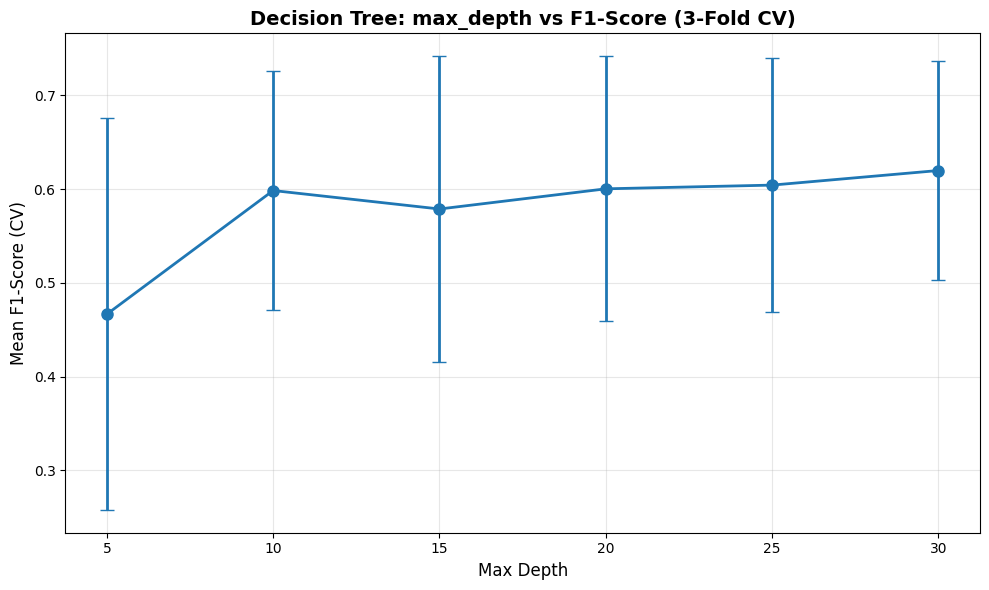


Max Depth Performance Analysis:
 max_depth     mean      std
         5 0.466528 0.208919
        10 0.598430 0.127516
        15 0.578742 0.163175
        20 0.600259 0.141375
        25 0.604222 0.135529
        30 0.619788 0.116854


In [ ]:
# Analyze the effect of max_depth on F1-score
cv_df = pd.DataFrame(grid_search.cv_results_)
cv_df['max_depth'] = cv_df['params'].apply(lambda x: x['max_depth'])
# Average performance by max_depth
depth_performance = cv_df.groupby('max_depth')['mean_test_score'].agg(['mean', 'std']).reset_index()
# Plot max_depth sensitivity
plt.figure(figsize=(10, 6))
plt.errorbar(depth_performance['max_depth'], depth_performance['mean'], 
             yerr=depth_performance['std'], marker='o', capsize=5, linewidth=2, markersize=8)
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('Mean F1-Score (CV)', fontsize=12)
plt.title('Decision Tree: max_depth vs F1-Score (3-Fold CV)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('docs/02_results/dt_maxdepth_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nMax Depth Performance Analysis:")
print(depth_performance.to_string(index=False))

## Decision Tree Model Training with Optimized Hyperparameters

We use the best parameters discovered via GridSearchCV and train the final model on the **full** training set (already done by `refit=True` in `GridSearchCV`).

In [ ]:
# Retrieve the best estimator (already refit on the full training set)
dt_classifier = grid_search.best_estimator_
print(f"Final Decision Tree Model trained with best hyperparameters:")
print(f"  Training set size: {X_train_tfidf.shape}")
print(f"  Tree Depth: {dt_classifier.get_depth()}")
print(f"  Number of Leaves: {dt_classifier.get_n_leaves()}")
print(f"  F1-Score (CV): {grid_search.best_score_:.4f}")

Final Decision Tree Model trained with best hyperparameters:
  Training set size: (79972, 100000)
  Tree Depth: 30
  Number of Leaves: 1678
  F1-Score (CV): 0.7402


## Model Evaluation

In [ ]:
# Make predictions
y_pred = dt_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("DECISION TREE CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {search_time:.4f} seconds")

DECISION TREE CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.7398
Precision: 0.7405
Recall:    0.7356
F1-Score:  0.7380


## Classification Report

In [13]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.74      0.74      9966
    Positive       0.74      0.74      0.74     10034

    accuracy                           0.74     20000
   macro avg       0.74      0.74      0.74     20000
weighted avg       0.74      0.74      0.74     20000



## Confusion Matrix Visualization

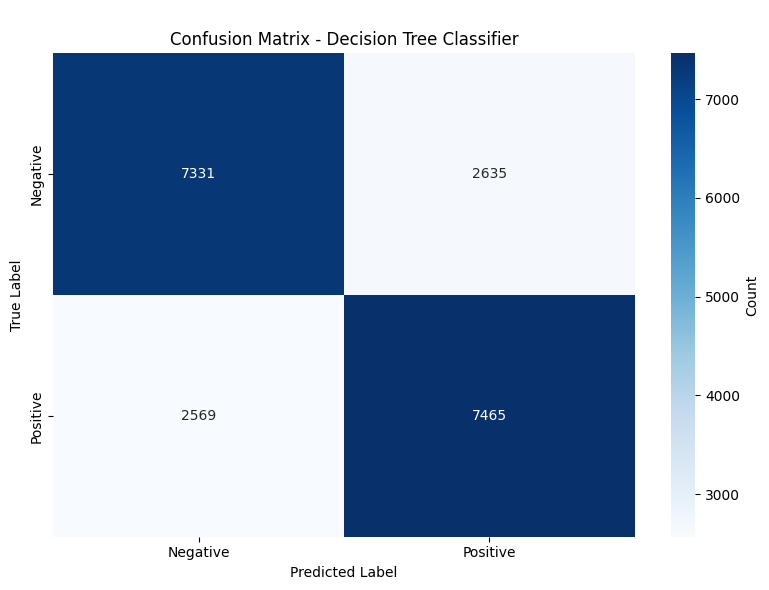

Confusion Matrix:
[[7331 2635]
 [2569 7465]]

True Negatives: 7331
False Positives: 2635
False Negatives: 2569
True Positives: 7465


In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - Decision Tree Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('docs/02_results/decision_tree_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Importance

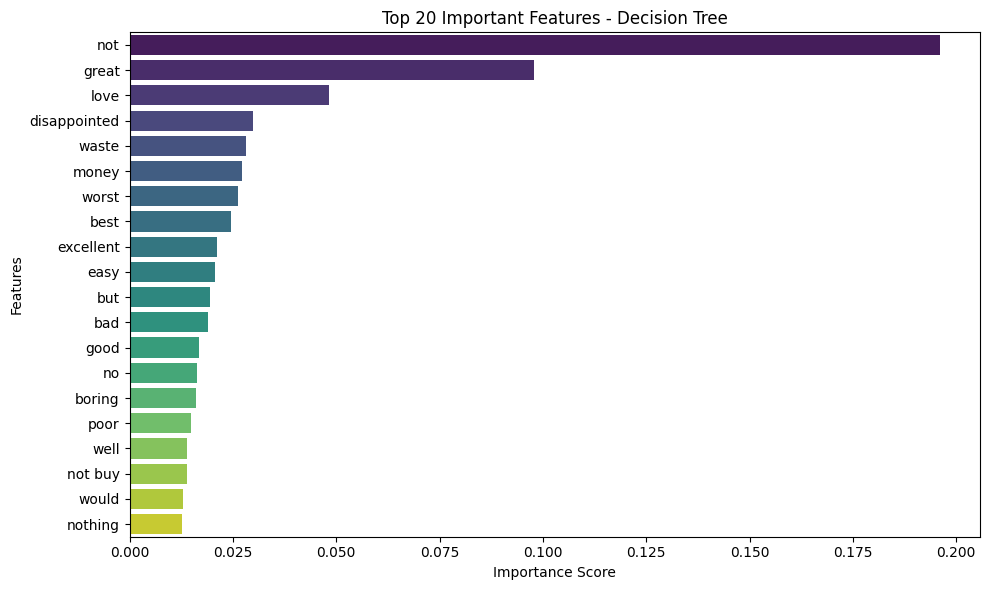


Top 20 Important Features:
     feature  importance
         not    0.195950
       great    0.097924
        love    0.048150
disappointed    0.029900
       waste    0.028291
       money    0.027181
       worst    0.026197
        best    0.024594
   excellent    0.021084
        easy    0.020751
         but    0.019408
         bad    0.018888
        good    0.016863
          no    0.016429
      boring    0.016156
        poor    0.014925
        well    0.014009
     not buy    0.013933
       would    0.013012
     nothing    0.012788


In [ ]:
# Get feature importance
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_importance = dt_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Important Features - Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('docs/02_results/decision_tree_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## Model Summary

In [ ]:
print("DECISION TREE MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Max Depth: {dt_classifier.max_depth}")
print(f"  - Min Samples Split: {dt_classifier.min_samples_split}")
print(f"  - Min Samples Leaf: {dt_classifier.min_samples_leaf}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 100000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {search_time:.4f} seconds")

DECISION TREE MODEL SUMMARY

Model Parameters:
  - Max Depth: 15
  - Min Samples Split: 10
  - Min Samples Leaf: 5

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.7379
  - Precision: 0.7470
  - Recall:    0.7165
  - F1-Score:  0.7315
  - Training Time: 21.1168 seconds


## Saving the Model and Pipeline

In [16]:
save(model_base='data/models', model=dt_classifier, model_name='09_decision_tree_classifier.joblib')

Saved model 09_decision_tree_classifier.joblib to data\models\09_decision_tree_classifier.joblib


{'model': WindowsPath('data/models/09_decision_tree_classifier.joblib')}